Hi, this is a test text with an equation: $a=b$

In [1]:
%matplotlib widget

In [2]:
import importlib
import field
importlib.reload(field)

from field import Field


In [3]:
# if you changed the code in field.py, run the above cell first
import os
from datetime import date

#datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\2024-1-02'

qadate = date(2024, 1, 2)
formatted_date = qadate.strftime("%Y-%m-%d")
datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date

# this specific format of the date is currently created in the __main__ of RetrieveFieldData.py
# TODO: change that


if not os.path.isdir(datafolder):
    formatted_date = f"{qadate.year}-{qadate.month}-{qadate.strftime('%d')}"
    datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date



# example of a Varian field: (field B2 for MRN 3102335 )
# ---------------------------
# filename = datafolder+'\\'+'FieldID_2406983.json' # make sure that this available locally on the computer (and not just in the cloud)

# in order to find that out, run the file RetrieveFieldData.py with the breakpoint() set 
# Q:\VMAT QA Project\Engineered Features>python RetrieveFieldData.py 2024 01 02 and then (Pdb) selection_augmented.query("FieldID == 2406983")


# example of an Elekta field (C2 for MRN 7211873):
# --------------------------
#filename = datafolder+'\\'+'FieldID_2406771.json'

# test field with 2 control points:
# -----------
filename = 'Q:\\VMAT QA Project\\Engineered Features\\Georg Mandl\\TestField_2403370.json'

field = Field(filename)
# %store field



In [10]:

import numpy as np

#print(field.cp[0]['leafSetA'])
#print(field.cp[0]['leafSetB'])

#leafposA = field.cp[0]['leafSetA']

#print(field.mq_control_points[0]['leafSetA'][field.active_leaf_start:field.active_leaf_end])
#print(field.matrixA)

# for viewing in data wrangler:
Aside = field.matrixA
BSide = field.matrixB

leafgaps = Aside+BSide



leaf_widths = np.array(field.leaf_width[leafgaps.index.min()-1: leafgaps.index.max()-1+1]) 
# just leafs matching the dataframe leafgaps, leafgaps.index indicates the leaf number starting at 1, field.leaf_width starts at index 0, the +1 makes the second index inclusive! 


areas = leafgaps.mul(leaf_widths[:, np.newaxis])

#areas[:] = 1.0 # Just to see if the summation below makes sense! 

# This trick thanks to chatGPT
ranges = {col: (field.exposed_leaf_start[areas.columns.get_loc(col)], field.exposed_leaf_end[areas.columns.get_loc(col)]) for col in areas.columns}

sums = {col: areas[col].loc[start:end].sum() for col, (start, end) in ranges.items()}

print(areas.sum()) # This was Goerge's old code 




181    14.0
1      14.0
dtype: float64


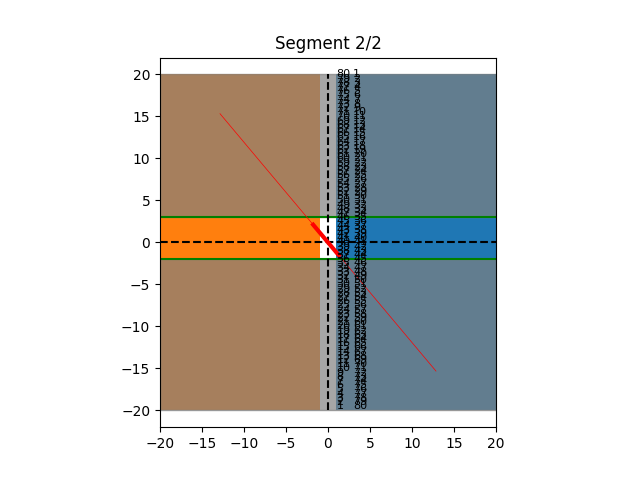

Collimator X1 =  3
Collimator X2 =  2
Collimator Y1 =  None
Collimator Y2 =  None
35
44
35    1.0
36    1.0
37    1.0
38    1.0
39    1.0
40    1.0
41    1.0
42    1.0
43    1.0
44    1.0
Name: 1, dtype: float64
40
-1.9833653851447508
2.7494098282637287


In [4]:
### In this cell, we are testing the plotting capabilities
### -------------------------------------------------------
#from plotting_HK import plot_segment 
# # I changed Georg's original code to use the field as the first parameter, and not field_info which is not directly returned with Field()

# have to reimport this function whenever we change the function plot_segment()
import importlib
import plotting_HK
importlib.reload(plotting_HK)

from plotting_HK import plot_segment

segmentno = 1 # with 0 the first
plot_segment(field, segmentno)

print('Collimator X1 = ', field.cp[segmentno]['collimatorX1'])
print('Collimator X2 = ', field.cp[segmentno]['collimatorX2'])
print('Collimator Y1 = ', field.cp[segmentno]['collimatorY1'])
print('Collimator Y2 = ', field.cp[segmentno]['collimatorY2'])

print(field.exposed_leaf_start[segmentno])
print(field.exposed_leaf_end[segmentno])


print(field.matrixA.loc[field.exposed_leaf_start[segmentno]:field.exposed_leaf_end[segmentno], 
                        field.matrixA.columns[segmentno]])

print(field.collimatorAngle)
print(field.cp[segmentno]['spanMin'])
print(field.cp[segmentno]['spanMax'])


In [ ]:
### Some testing with the Metadatafile
import os
import pandas as pd

qadate = date(2024, 1, 2)
formatted_date = qadate.strftime("%Y-%m-%d")
datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date
# the specific format of the date is currently created in the __main__ of RetrieveFieldData.py
# TODO: change that


if not os.path.isdir(datafolder):
    formatted_date = f"{qadate.year}-{qadate.month}-{qadate.strftime('%d')}"
    datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date

mdfiles = [f for f in os.listdir(datafolder) if f.startswith('FieldsMetaData') and os.path.isfile(os.path.join(datafolder, f))]
file_name = os.path.join(datafolder, mdfiles[0])

df = pd.read_json(file_name)


# TODO: read all field data files in that folder
#  extract the span from each field
# add a column to df with the span
# write the amended df to a new metadata file

In [5]:
%reset -f